# Exploratory Data Analysis
## Requested Analysis  
### Action 1
*Further interrogate the figures in BUS01e and produce a graph comparing total bus patronage growth in Warwickshire between 2022 - 2025 to that in other similar neighbouring Local Authority areas, i.e. Worcestershire, Staffordshire, West Northamptonshire, Shropshire, Gloucestershire, Leicestershire and Oxfordshire.*

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('Bus01e.csv')
df.head()

,Local Authority (LA) Code,LA or Region,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,E12000001,North East,207.2,205.6,198.6,190.4,188.3,184.9,180.6,177.0,169.0,171.6,159.8,61.1,113.0,129.2,130.6,139.0
1,E06000005,Darlington,8.2,7.9,7.0,6.6,6.6,6.5,6.2,6.3,6.0,5.7,5.5,1.7,3.6,3.5,4.1,4.0
2,E06000047,Durham,26.3,25.9,24.7,23.1,23.2,22.8,22.1,21.9,21.7,22.1,20.8,9.0,17.6,16.1,17.2,17.6
3,E06000001,Hartlepool,5.4,5.3,4.8,4.6,4.6,4.7,4.7,4.4,4.3,4.4,4.0,1.6,2.8,3.4,3.6,3.5
4,E06000002,Middlesbrough,10.2,10.4,9.8,9.1,9.0,8.4,9.1,8.4,7.3,7.4,6.8,2.5,4.8,6.0,6.6,6.5


In [37]:
# Cleaning and preparing data for analysis
# Identify all year columns (e.g., "2010" … "2025")
year_cols = [c for c in df.columns if c.isdigit()]

# Melt
df_long = df.melt(
    id_vars=["LA or Region"],
    value_vars=year_cols,
    var_name="Year",
    value_name="Passenger_Journeys_Millions"
)

# Convert types
df_long["Year"] = df_long["Year"].astype(int)
df_long["Passenger_Journeys_Millions"] = pd.to_numeric(
    df_long["Passenger_Journeys_Millions"],
    errors="coerce"
)

# Convert years to numbers
df_long["Year"] = df_long["Year"].astype(int)

# Keep only 2022–2025
df_long = df_long[df_long["Year"].between(2022, 2025)]

# Authorities for comparison
target_areas = [
    "Warwickshire",
    "Worcestershire",
    "Staffordshire",
    "West Northamptonshire",
    "Shropshire",
    "Gloucestershire",
    "Leicestershire"
]

# Filter to only those in the dataset
df_filtered = df_long[df_long["LA or Region"].isin(target_areas)]


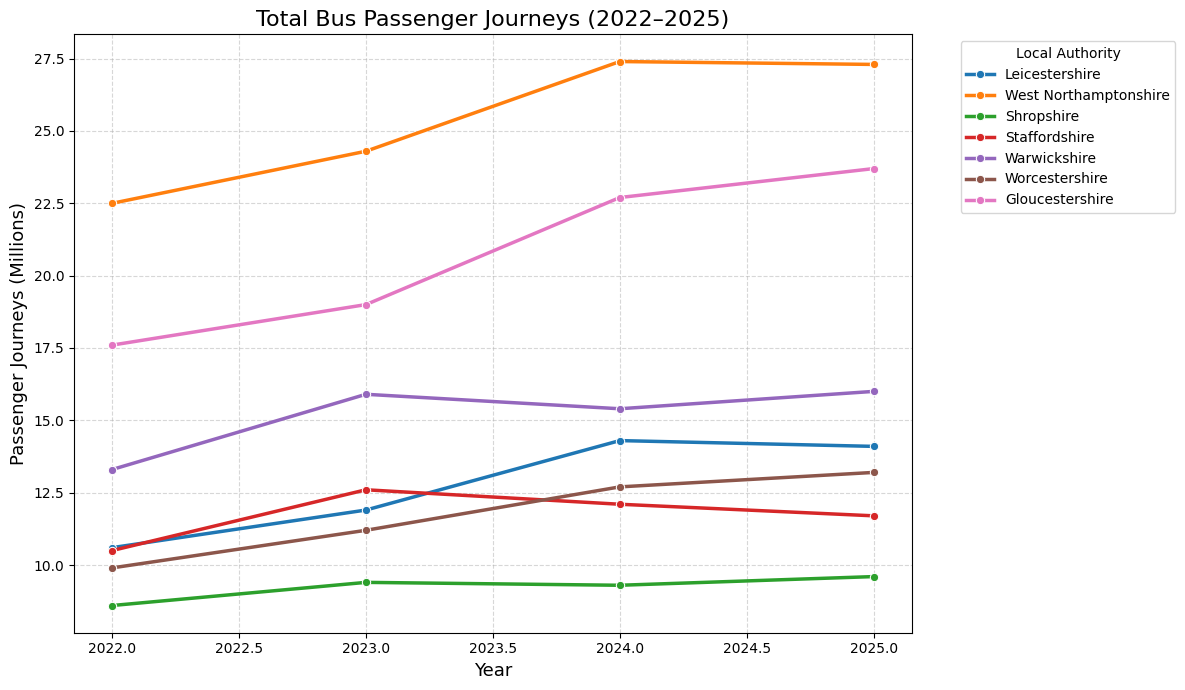

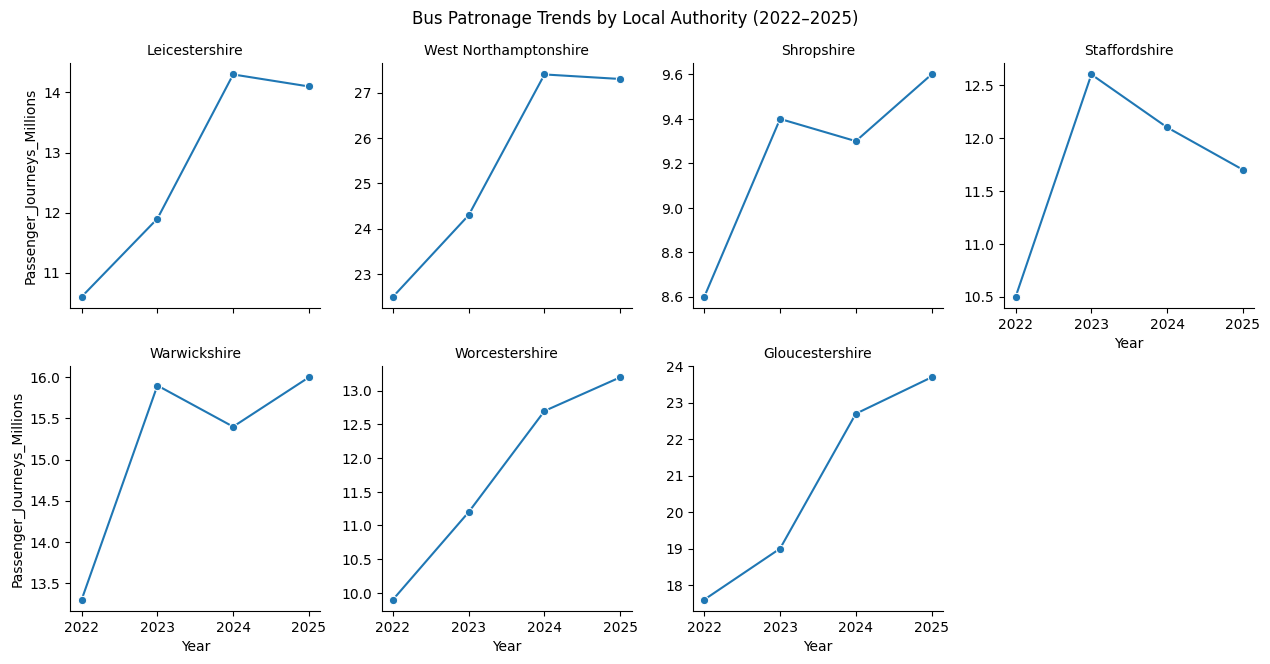

In [38]:
# Plot Action 1: Line plot comparing bus patronage trends across selected local authorities

plt.figure(figsize=(12, 7))
sns.lineplot(
    data=df_filtered,
    x="Year",
    y="Passenger_Journeys_Millions",
    hue="LA or Region",
    marker="o",
    linewidth=2.5
)

plt.title("Total Bus Passenger Journeys (2022–2025)", fontsize=16)
plt.xlabel("Year", fontsize=13)
plt.ylabel("Passenger Journeys (Millions)", fontsize=13)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(title="Local Authority", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

plt.show()

# Faceted line plots for each authority to show trends more clearly
g = sns.FacetGrid(
    df_filtered,
    col="LA or Region",
    col_wrap=4,
    height=3.2,
    sharey=False
)

g.map_dataframe(sns.lineplot, x="Year", y="Passenger_Journeys_Millions", marker="o")
g.set_titles("{col_name}")
g.fig.suptitle("Bus Patronage Trends by Local Authority (2022–2025)", y=1.03)

plt.show()

### Action 2
**Interrogate all other Warwickshire specific based data in the document, i.e., BUS01f (Bus Passenger Journeys on Local Bus Services per head by Local Authority), and BUS01g (Elderly and Disabled Concessionary Passenger Journeys on Local Bus Services by Local Authority), and BUS01h (Elderly and Disabled Concessionary Passenger Journeys on Local Bus Services by Local Authority as a Percentage of Total Passenger Journeys), and conduct the following tasks:** 

*Extrapolate the respective data into graphs replicating that already produced for BUS01e above; interrogate the respective figures and produce a graph comparing figures for Warwickshire between 2022 - 2025 to that in other similar neighbouring Local Authority areas, i.e. Worcestershire, Staffordshire, West Northamptonshire, Shropshire, Gloucestershire and Leicestershire and Oxfordshire*

**BUS01f**

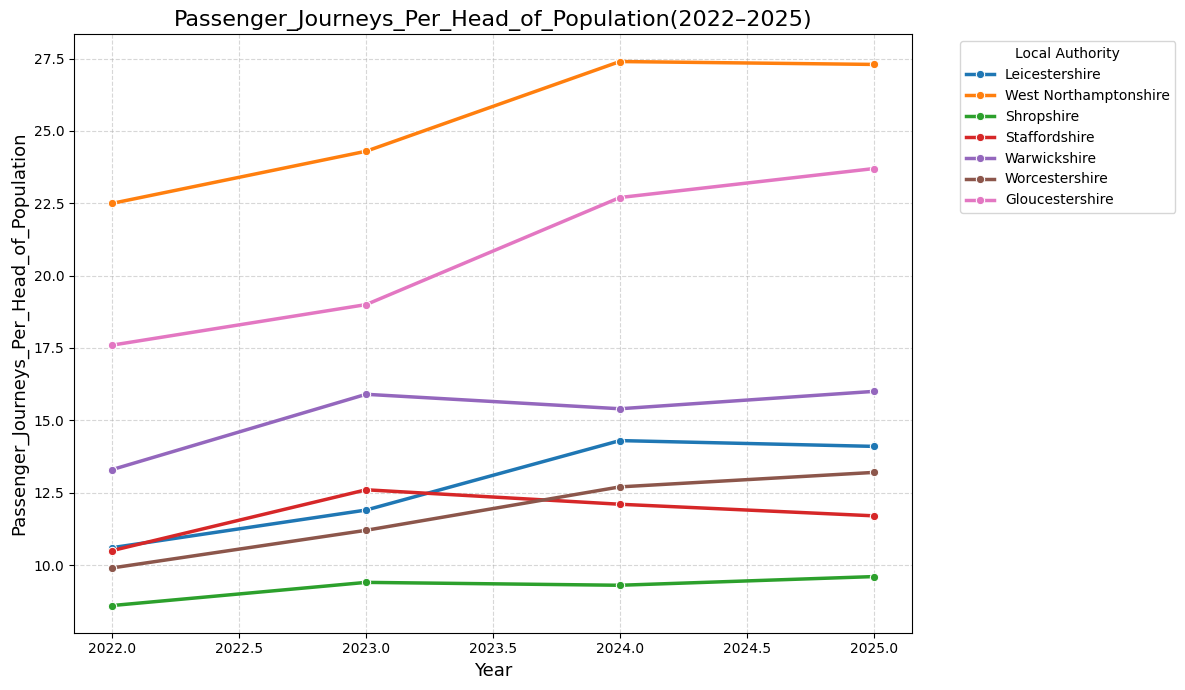

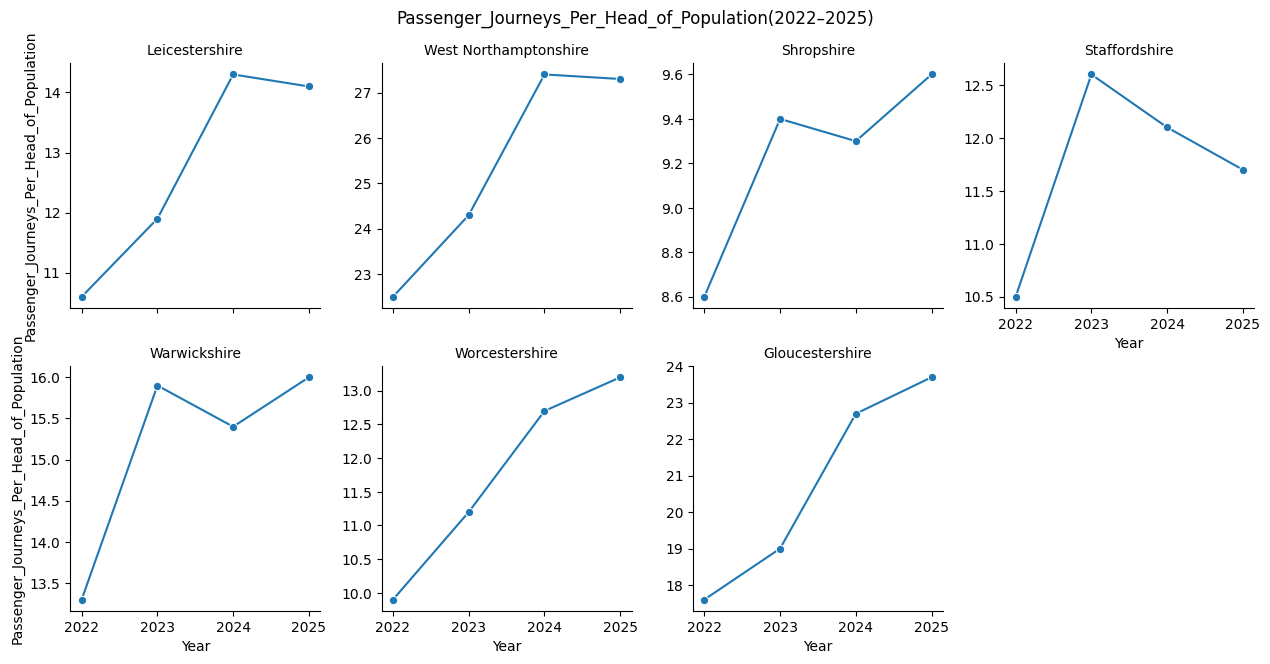

In [39]:
df = pd.read_csv("Bus01f.csv")

# Cleaning and preparing data for analysis
# Identify all year columns (e.g., "2010" … "2025")
year_cols = [c for c in df.columns if c.isdigit()]

# Melt
df_long = df.melt(
    id_vars=["LA or Region"],
    value_vars=year_cols,
    var_name="Year",
    value_name="Passenger_Journeys_Per_Head_of_Population"
)

# Convert types
df_long["Year"] = df_long["Year"].astype(int)
df_long["Passenger_Journeys_Per_Head_of_Population"] = pd.to_numeric(
    df_long["Passenger_Journeys_Per_Head_of_Population"],
    errors="coerce"
)

# Convert years to numbers
df_long["Year"] = df_long["Year"].astype(int)

# Keep only 2022–2025
df_long = df_long[df_long["Year"].between(2022, 2025)]

# Authorities for comparison
target_areas = [
    "Warwickshire",
    "Worcestershire",
    "Staffordshire",
    "West Northamptonshire",
    "Shropshire",
    "Gloucestershire",
    "Leicestershire"
]

# Filter to only those in the dataset
df_filtered = df_long[df_long["LA or Region"].isin(target_areas)]

# Plot Action 1: Line plot comparing bus patronage trends across selected local authorities

plt.figure(figsize=(12, 7))
sns.lineplot(
    data=df_filtered,
    x="Year",
    y="Passenger_Journeys_Per_Head_of_Population",
    hue="LA or Region",
    marker="o",
    linewidth=2.5
)

plt.title("Passenger_Journeys_Per_Head_of_Population(2022–2025)", fontsize=16)
plt.xlabel("Year", fontsize=13)
plt.ylabel("Passenger_Journeys_Per_Head_of_Population", fontsize=13)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(title="Local Authority", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

plt.show()

# Faceted line plots for each authority to show trends more clearly
g = sns.FacetGrid(
    df_filtered,
    col="LA or Region",
    col_wrap=4,
    height=3.2,
    sharey=False
)

g.map_dataframe(sns.lineplot, x="Year", y="Passenger_Journeys_Per_Head_of_Population", marker="o")
g.set_titles("{col_name}")
g.fig.suptitle("Passenger_Journeys_Per_Head_of_Population(2022–2025)", y=1.03)

plt.show()




**BUS01g**

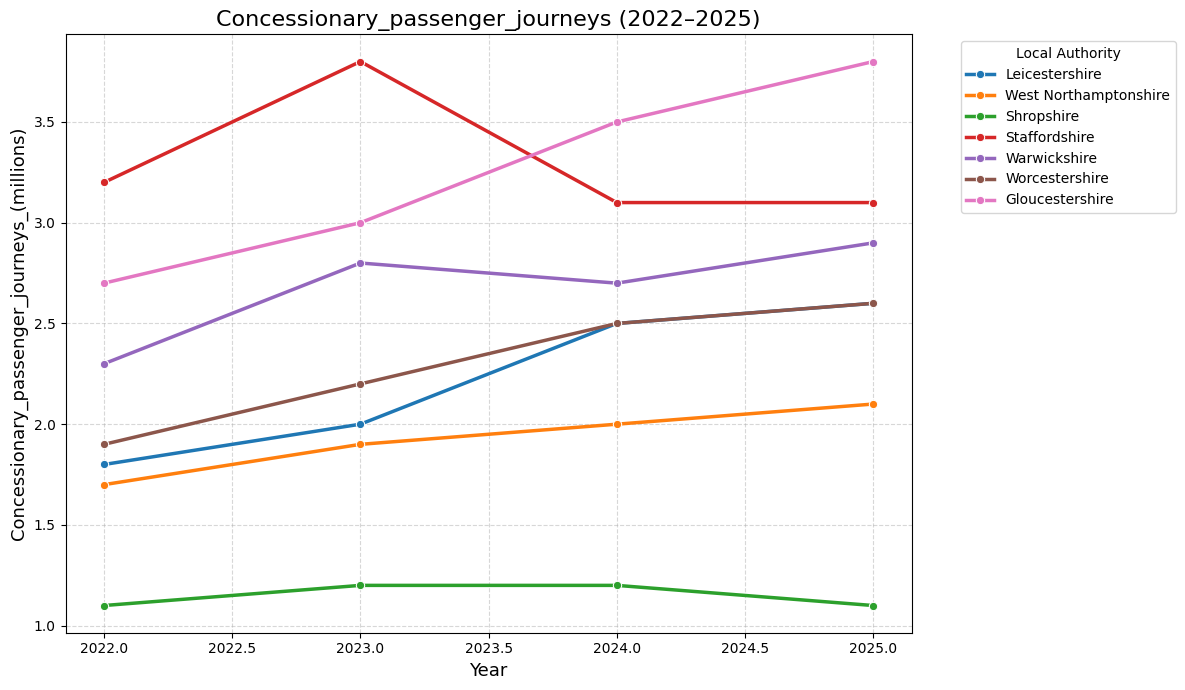

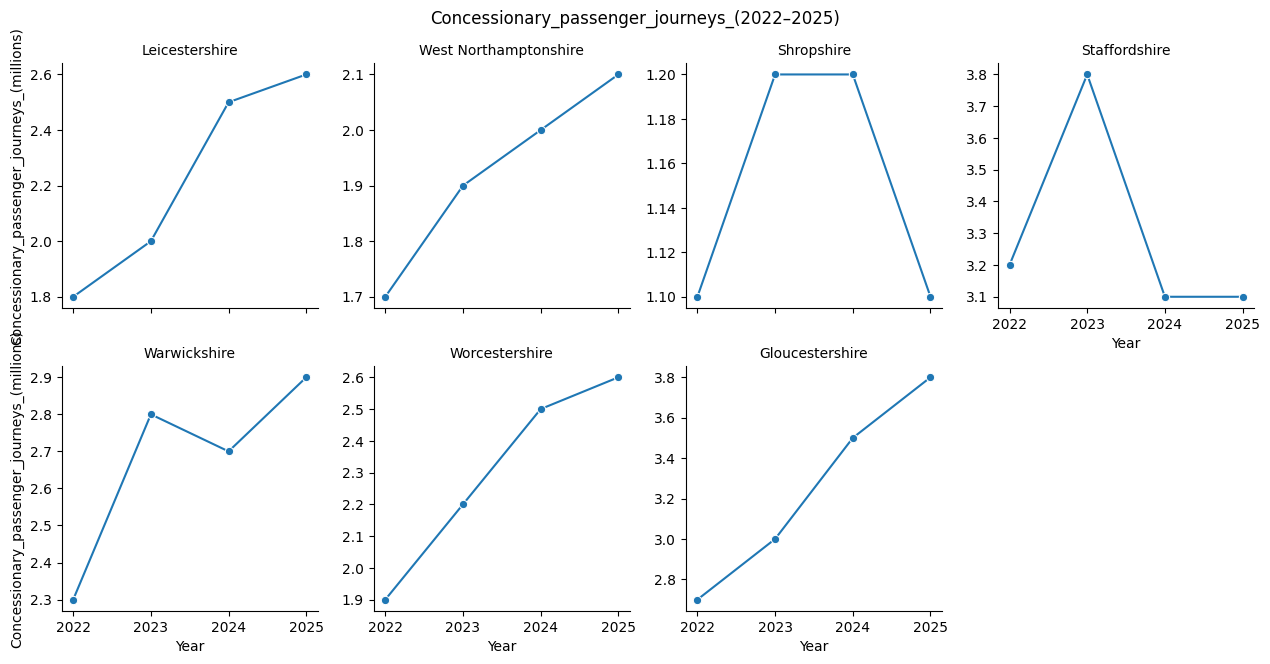

In [48]:
df = pd.read_csv("Bus01g.csv")

# Cleaning and preparing data for analysis
# Identify all year columns (e.g., "2010" … "2025")
year_cols = [c for c in df.columns if c.isdigit()]

# Melt
df_long = df.melt(
    id_vars=["LA or Region"],
    value_vars=year_cols,
    var_name="Year",
    value_name="Concessionary_passenger_journeys_(millions)"
)

# Convert types
df_long["Year"] = df_long["Year"].astype(int)
df_long["Concessionary_passenger_journeys_(millions)"] = pd.to_numeric(
    df_long["Concessionary_passenger_journeys_(millions)"],
    errors="coerce"
)

# Convert years to numbers
df_long["Year"] = df_long["Year"].astype(int)

# Keep only 2022–2025
df_long = df_long[df_long["Year"].between(2022, 2025)]

# Authorities for comparison
target_areas = [
    "Warwickshire",
    "Worcestershire",
    "Staffordshire",
    "West Northamptonshire",
    "Shropshire",
    "Gloucestershire",
    "Leicestershire"
]

# Filter to only those in the dataset
df_filtered = df_long[df_long["LA or Region"].isin(target_areas)]

# Plot Action 1: Line plot comparing bus patronage trends across selected local authorities

plt.figure(figsize=(12, 7))
sns.lineplot(
    data=df_filtered,
    x="Year",
    y="Concessionary_passenger_journeys_(millions)",
    hue="LA or Region",
    marker="o",
    linewidth=2.5
)

plt.title("Concessionary_passenger_journeys (2022–2025)", fontsize=16)
plt.xlabel("Year", fontsize=13)
plt.ylabel("Concessionary_passenger_journeys_(millions)", fontsize=13)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(title="Local Authority", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

plt.show()

# Faceted line plots for each authority to show trends more clearly
g = sns.FacetGrid(
    df_filtered,
    col="LA or Region",
    col_wrap=4,
    height=3.2,
    sharey=False
)

g.map_dataframe(sns.lineplot, x="Year", y="Concessionary_passenger_journeys_(millions)", marker="o")
g.set_titles("{col_name}")
g.fig.suptitle("Concessionary_passenger_journeys_(2022–2025)", y=1.03)

plt.show()




**BUS01h**

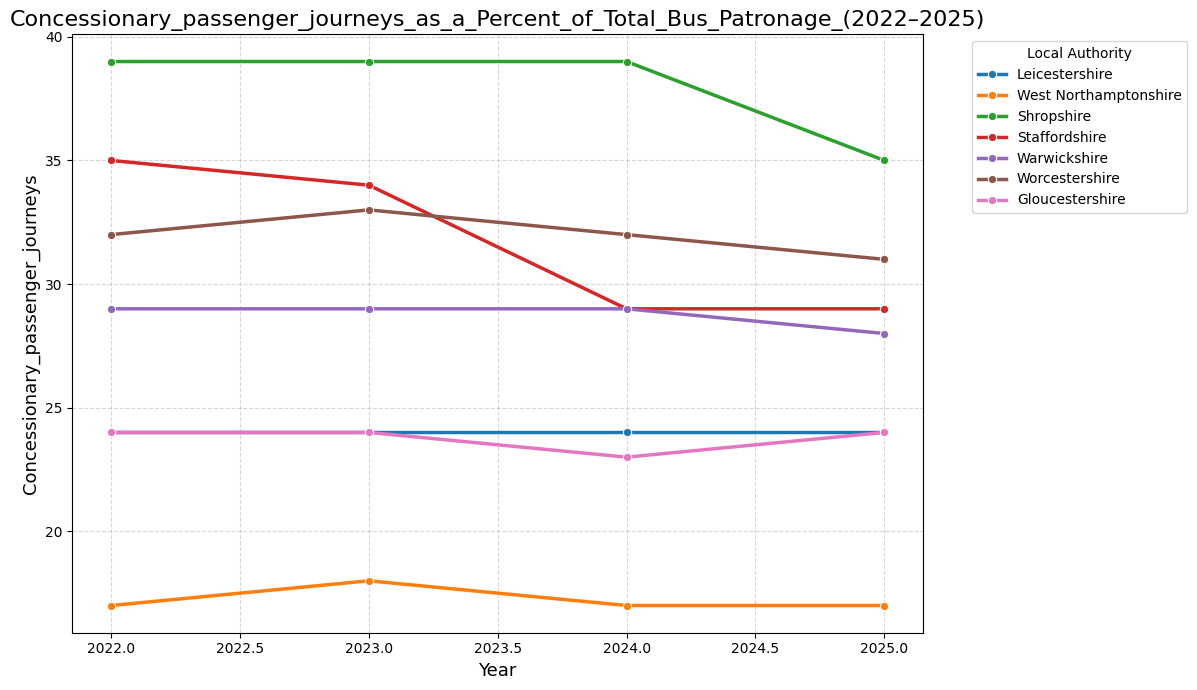

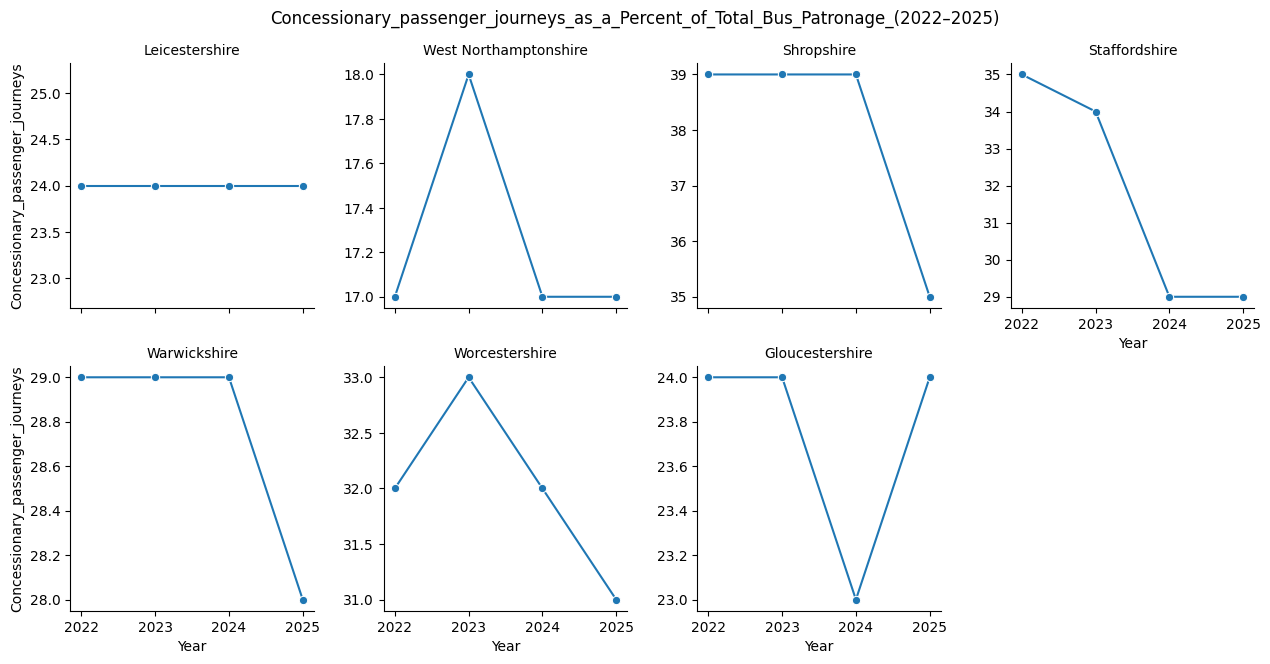

In [50]:
df = pd.read_csv("Bus01h.csv")

# Cleaning and preparing data for analysis
# Identify all year columns (e.g., "2010" … "2025")
year_cols = [c for c in df.columns if c.isdigit()]

# Melt
df_long = df.melt(
    id_vars=["LA or Region"],
    value_vars=year_cols,
    var_name="Year",
    value_name="Concessionary_passenger_journeys"
)

# Convert types
df_long["Year"] = df_long["Year"].astype(int)
df_long["Concessionary_passenger_journeys"] = pd.to_numeric(
    df_long["Concessionary_passenger_journeys"],
    errors="coerce"
)

# Convert years to numbers
df_long["Year"] = df_long["Year"].astype(int)

# Keep only 2022–2025
df_long = df_long[df_long["Year"].between(2022, 2025)]

# Authorities for comparison
target_areas = [
    "Warwickshire",
    "Worcestershire",
    "Staffordshire",
    "West Northamptonshire",
    "Shropshire",
    "Gloucestershire",
    "Leicestershire"
]

# Filter to only those in the dataset
df_filtered = df_long[df_long["LA or Region"].isin(target_areas)]

# Plot Action 1: Line plot comparing bus patronage trends across selected local authorities

plt.figure(figsize=(12, 7))
sns.lineplot(
    data=df_filtered,
    x="Year",
    y="Concessionary_passenger_journeys",
    hue="LA or Region",
    marker="o",
    linewidth=2.5
)

plt.title("Concessionary_passenger_journeys_as_a_Percent_of_Total_Bus_Patronage_(2022–2025)", fontsize=16)
plt.xlabel("Year", fontsize=13)
plt.ylabel("Concessionary_passenger_journeys", fontsize=13)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(title="Local Authority", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

plt.show()

# Faceted line plots for each authority to show trends more clearly
g = sns.FacetGrid(
    df_filtered,
    col="LA or Region",
    col_wrap=4,
    height=3.2,
    sharey=False
)

g.map_dataframe(sns.lineplot, x="Year", y="Concessionary_passenger_journeys", marker="o")
g.set_titles("{col_name}")
g.fig.suptitle("Concessionary_passenger_journeys_as_a_Percent_of_Total_Bus_Patronage_(2022–2025)", y=1.03)

plt.show()




**Brief commentary on key findings detailing the performance of Warwickshire compared to other similar Local Authorities**
>